In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict
import string

In [7]:
class Stats(TypedDict):
    runs : int
    balls : int
    fours : int 
    sixes : int 
    strikeRate : float 
    ballsPerBoundary : float
    boudaryPer : float
    summary:string

In [25]:
def calc_strikeRate(state:Stats)->Stats:
    runs = state['runs']
    balls = state['balls']
    sr = round((runs/balls*100.0),2)
    return {'strikeRate':sr}

In [26]:
def calc_ballsPerBoundary(state:Stats)->Stats:
    fours = state['fours']
    sixes = state['sixes']
    balls = state['balls']
    bpb = round(1.0*(balls)/(fours+sixes),2)
    return {'ballsPerBoundary':bpb}

In [27]:
def calc_boudaryPerc(state:Stats)->Stats:
    bp = round((state['sixes']+state['fours'])/state['balls']*100,2)
    return {'boudaryPer':bp}

In [28]:
def summary(state:Stats)->Stats:
    model = ChatOllama(model='llama3.2:3b',temperature=0)
    prompt = f"give my the summary for the players perfomance in cricket matches . strike rate : {state['strikeRate']} , balls per boundary : {state['ballsPerBoundary']} , boundary percent : {state['boudaryPer']} "
    state['summary'] = model.invoke(prompt).content
    return state

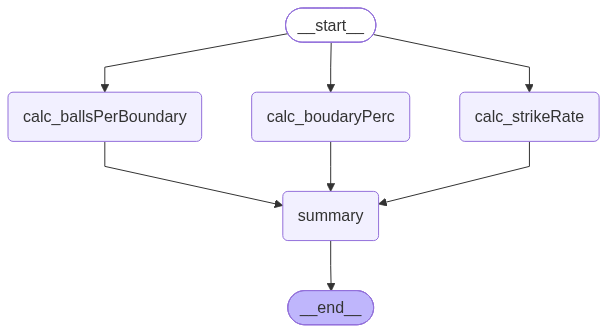

In [29]:
graph = StateGraph(Stats)
graph.add_node('calc_strikeRate',calc_strikeRate)
graph.add_node('calc_ballsPerBoundary',calc_ballsPerBoundary)
graph.add_node('calc_boudaryPerc',calc_boudaryPerc)
graph.add_node('summary',summary)

graph.add_edge(START,'calc_strikeRate')
graph.add_edge(START,'calc_ballsPerBoundary')
graph.add_edge(START,'calc_boudaryPerc')
graph.add_edge('calc_ballsPerBoundary','summary')
graph.add_edge('calc_boudaryPerc','summary')
graph.add_edge('calc_strikeRate','summary')
graph.add_edge('summary',END)
workflow = graph.compile()
workflow

In [30]:
final_state = workflow.invoke({'runs':100,'balls':30,'fours':3,'sixes':2})
print(final_state)

{'runs': 100, 'balls': 30, 'fours': 3, 'sixes': 2, 'strikeRate': 333.33, 'ballsPerBoundary': 6.0, 'boudaryPer': 16.67, 'summary': "Based on the provided statistics, here's a summary of the player's performance in cricket matches:\n\n**Strike Rate:** 333.33\n\n* This indicates that the player scores at an extremely high rate, with an average of approximately 333 runs per 1000 deliveries. This is significantly higher than the average strike rate in professional cricket.\n\n**Balls per Boundary:** 6.0\n\n* This suggests that the player takes approximately 6 deliveries to score a boundary. This is a very efficient rate, indicating that the player is able to score boundaries consistently and effectively.\n\n**Boundary Percent:** 16.67%\n\n* This indicates that the player scores approximately 16.67% of their total runs as boundaries. This is a relatively high percentage, suggesting that the player is a threat to the opposing team's bowling attack.\n\nOverall, these statistics suggest that th

In [31]:
print(final_state['summary'])

Based on the provided statistics, here's a summary of the player's performance in cricket matches:

**Strike Rate:** 333.33

* This indicates that the player scores at an extremely high rate, with an average of approximately 333 runs per 1000 deliveries. This is significantly higher than the average strike rate in professional cricket.

**Balls per Boundary:** 6.0

* This suggests that the player takes approximately 6 deliveries to score a boundary. This is a very efficient rate, indicating that the player is able to score boundaries consistently and effectively.

**Boundary Percent:** 16.67%

* This indicates that the player scores approximately 16.67% of their total runs as boundaries. This is a relatively high percentage, suggesting that the player is a threat to the opposing team's bowling attack.

Overall, these statistics suggest that the player is an aggressive and efficient batsman who is able to score runs quickly and consistently. They are likely to be a key player in their t